##  Retail Sales Exploratory Data Analysis using Python

## Business Objective

This project aims to analyze retail sales data using Python to identify sales and profit trends, evaluate category, city, product, and customer performance, and understand monthly business patterns.

The analysis focuses on identifying top-performing and underperforming areas and generating actionable business insights from the sales data.

# 1. Import Libraries

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Load Dataset

In [14]:
sales_data = pd.read_excel(r"E:\retail-sales-eda-python\data\retail_sales_dataset.xlsx")

# 3. Data Understanding

In [15]:
sales_data.head(20)

,Order_ID,Customer,City,Category,Product,Quantity,Sales,Profit,Order_Date
0,1001,Arun,Chennai,Electronics,Laptop,2,100000,15000,2025-01-05
1,1002,Priya,Madurai,Furniture,Chair,4,24000,4000,2025-01-12
2,1003,Kumar,Coimbatore,Electronics,Mobile,3,45000,7000,2025-01-20
3,1004,Divya,Salem,Office Supplies,Notebook,10,5000,1200,2025-02-03
4,1005,Ravi,Chennai,Furniture,Table,2,30000,5000,2025-02-15
5,1006,Meena,Madurai,Electronics,Headphones,5,15000,3000,2025-02-25
6,1007,Arun,Chennai,Office Supplies,Pen,20,3000,800,2025-03-02
7,1008,Priya,Coimbatore,Electronics,Tablet,3,60000,9000,2025-03-18
8,1009,Suresh,Salem,Furniture,Chair,4,22000,3500,2025-03-25
9,1010,Kumar,Chennai,Electronics,Laptop,1,55000,8500,2025-04-05


In [16]:
sales_data.shape

(20, 9)

In [17]:
sales_data.columns.tolist()

['Order_ID',
 'Customer',
 'City',
 'Category',
 'Product',
 'Quantity',
 'Sales',
 'Profit',
 'Order_Date']

In [18]:
sales_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Order_ID    20 non-null     int64         
 1   Customer    20 non-null     object        
 2   City        20 non-null     object        
 3   Category    20 non-null     object        
 4   Product     20 non-null     object        
 5   Quantity    20 non-null     int64         
 6   Sales       20 non-null     int64         
 7   Profit      20 non-null     int64         
 8   Order_Date  20 non-null     datetime64[ns]
dtypes: datetime64[ns](1), int64(4), object(4)
memory usage: 1.5+ KB


In [19]:
sales_data.describe()

,Order_ID,Quantity,Sales,Profit
count,20.00000,20.000000,20.000000,20.000000
mean,1010.50000,5.800000,34125.000000,5535.000000
std,5.91608,4.916139,29823.001985,4545.706476
min,1001.00000,1.000000,3000.000000,800.000000
25%,1005.75000,3.000000,13050.000000,2575.000000
50%,1010.50000,4.000000,27500.000000,4750.000000
75%,1015.25000,6.500000,46250.000000,7125.000000
max,1020.00000,20.000000,110000.000000,18000.000000


# 4. Data Quality Check

In [20]:
sales_data.isnull().sum()

Order_ID      0
Customer      0
City          0
Category      0
Product       0
Quantity      0
Sales         0
Profit        0
Order_Date    0
dtype: int64

In [21]:
sales_data.duplicated().sum()

0

In [22]:
sales_data.dtypes

Order_ID               int64
Customer              object
City                  object
Category              object
Product               object
Quantity               int64
Sales                  int64
Profit                 int64
Order_Date    datetime64[ns]
dtype: object

In [23]:
sales_data['Customer'].nunique()

7

In [24]:
sales_data['City'].nunique()

4

# 5. Data Cleaning & Preparation

In [25]:
sales_data['City'] = sales_data['City'].str.lstrip()
sales_data

,Order_ID,Customer,City,Category,Product,Quantity,Sales,Profit,Order_Date
0,1001,Arun,Chennai,Electronics,Laptop,2,100000,15000,2025-01-05
1,1002,Priya,Madurai,Furniture,Chair,4,24000,4000,2025-01-12
2,1003,Kumar,Coimbatore,Electronics,Mobile,3,45000,7000,2025-01-20
3,1004,Divya,Salem,Office Supplies,Notebook,10,5000,1200,2025-02-03
4,1005,Ravi,Chennai,Furniture,Table,2,30000,5000,2025-02-15
5,1006,Meena,Madurai,Electronics,Headphones,5,15000,3000,2025-02-25
6,1007,Arun,Chennai,Office Supplies,Pen,20,3000,800,2025-03-02
7,1008,Priya,Coimbatore,Electronics,Tablet,3,60000,9000,2025-03-18
8,1009,Suresh,Salem,Furniture,Chair,4,22000,3500,2025-03-25
9,1010,Kumar,Chennai,Electronics,Laptop,1,55000,8500,2025-04-05


In [26]:
sales_data['City'] = sales_data['City'].str.upper()
sales_data

,Order_ID,Customer,City,Category,Product,Quantity,Sales,Profit,Order_Date
0,1001,Arun,CHENNAI,Electronics,Laptop,2,100000,15000,2025-01-05
1,1002,Priya,MADURAI,Furniture,Chair,4,24000,4000,2025-01-12
2,1003,Kumar,COIMBATORE,Electronics,Mobile,3,45000,7000,2025-01-20
3,1004,Divya,SALEM,Office Supplies,Notebook,10,5000,1200,2025-02-03
4,1005,Ravi,CHENNAI,Furniture,Table,2,30000,5000,2025-02-15
5,1006,Meena,MADURAI,Electronics,Headphones,5,15000,3000,2025-02-25
6,1007,Arun,CHENNAI,Office Supplies,Pen,20,3000,800,2025-03-02
7,1008,Priya,COIMBATORE,Electronics,Tablet,3,60000,9000,2025-03-18
8,1009,Suresh,SALEM,Furniture,Chair,4,22000,3500,2025-03-25
9,1010,Kumar,CHENNAI,Electronics,Laptop,1,55000,8500,2025-04-05


In [27]:
sales_data['Order_Date'] = pd.to_datetime(sales_data['Order_Date'])
sales_data

,Order_ID,Customer,City,Category,Product,Quantity,Sales,Profit,Order_Date
0,1001,Arun,CHENNAI,Electronics,Laptop,2,100000,15000,2025-01-05
1,1002,Priya,MADURAI,Furniture,Chair,4,24000,4000,2025-01-12
2,1003,Kumar,COIMBATORE,Electronics,Mobile,3,45000,7000,2025-01-20
3,1004,Divya,SALEM,Office Supplies,Notebook,10,5000,1200,2025-02-03
4,1005,Ravi,CHENNAI,Furniture,Table,2,30000,5000,2025-02-15
5,1006,Meena,MADURAI,Electronics,Headphones,5,15000,3000,2025-02-25
6,1007,Arun,CHENNAI,Office Supplies,Pen,20,3000,800,2025-03-02
7,1008,Priya,COIMBATORE,Electronics,Tablet,3,60000,9000,2025-03-18
8,1009,Suresh,SALEM,Furniture,Chair,4,22000,3500,2025-03-25
9,1010,Kumar,CHENNAI,Electronics,Laptop,1,55000,8500,2025-04-05


# 6. Exploratory Data Analysis

## 6.1 Basic Business KPIs

In [28]:
### Total Sales

sales_data['Sales'].sum()

682500

In [29]:
### Average Sales

sales_data['Sales'].mean()

34125.0

In [30]:
### Total Profit

sales_data['Profit'].sum()

110700

In [31]:
### Average Profit

sales_data['Profit'].mean()

5535.0

In [32]:
### Total Quantity

sales_data['Quantity'].sum()

116

## 6.2 Category Analysis

In [33]:
### Sales by Category

sales_data.groupby('Category')['Sales'].sum()

Category
Electronics        495000
Furniture          163000
Office Supplies     24500
Name: Sales, dtype: int64

In [34]:
### Maximum Sales by Category

sales_data.groupby('Category')['Sales'].max()

Category
Electronics        110000
Furniture           32000
Office Supplies      7200
Name: Sales, dtype: int64

In [35]:
### Profit by Category

sales_data.groupby('Category')['Profit'].sum()

Category
Electronics        78000
Furniture          27500
Office Supplies     5200
Name: Profit, dtype: int64

In [36]:
### Maximum Profit by Category

sales_data.groupby('Category')['Profit'].max()

Category
Electronics        18000
Furniture           5500
Office Supplies     1300
Name: Profit, dtype: int64

In [37]:
### Category Contribution

category_sales = sales_data.groupby('Category')['Sales'].sum()

category_percentage = (
    category_sales / sales_data['Sales'].sum()
) * 100

category_percentage.round(2)

Category
Electronics        72.53
Furniture          23.88
Office Supplies     3.59
Name: Sales, dtype: float64

## 6.3 City Analysis

In [38]:
### Sales by City

sales_data.groupby('City')['Sales'].sum()

City
CHENNAI       390000
COIMBATORE    139200
MADURAI        89800
SALEM          63500
Name: Sales, dtype: int64

In [39]:
### Profit by City

sales_data.groupby('City')['Profit'].sum()

City
CHENNAI       61300
COIMBATORE    21800
MADURAI       16500
SALEM         11100
Name: Profit, dtype: int64

In [40]:
### Orders by City

sales_data.groupby('City')['Order_ID'].count()

City
CHENNAI       7
COIMBATORE    4
MADURAI       5
SALEM         4
Name: Order_ID, dtype: int64

In [41]:
### Average Sales by City

sales_data.groupby('City')['Sales'].mean()

City
CHENNAI       55714.285714
COIMBATORE    34800.000000
MADURAI       17960.000000
SALEM         15875.000000
Name: Sales, dtype: float64

## 6.4 Product Analysis

In [42]:
### Sales by Product

sales_data.groupby('Product')['Sales'].sum()

Product
Chair          74000
Headphones     33000
Laptop        265000
Mobile        137000
Notebook       17000
Pen             7500
Table          89000
Tablet         60000
Name: Sales, dtype: int64

In [43]:
### Profit by Product

sales_data.groupby('Product')['Profit'].sum()

Product
Chair         12500
Headphones     6500
Laptop        41500
Mobile        21000
Notebook       3500
Pen            1700
Table         15000
Tablet         9000
Name: Profit, dtype: int64

In [44]:
### Quantity by Product

sales_data.groupby('Product')['Quantity'].sum()

Product
Chair         13
Headphones     9
Laptop         5
Mobile        13
Notebook      30
Pen           35
Table          8
Tablet         3
Name: Quantity, dtype: int64

In [45]:
### Top products by Sales

sales_data.groupby('Product')['Sales'].sum().sort_values(ascending= False).head(3)

Product
Laptop    265000
Mobile    137000
Table      89000
Name: Sales, dtype: int64

In [46]:
### Top products by Profit

sales_data.groupby('Product')['Profit'].sum().sort_values(ascending= False)

Product
Laptop        41500
Mobile        21000
Table         15000
Chair         12500
Tablet         9000
Headphones     6500
Notebook       3500
Pen            1700
Name: Profit, dtype: int64

In [47]:
### Average profit by product

sales_data.groupby('Product')['Profit'].mean()

Product
Chair          4166.666667
Headphones     3250.000000
Laptop        13833.333333
Mobile         7000.000000
Notebook       1166.666667
Pen             850.000000
Table          5000.000000
Tablet         9000.000000
Name: Profit, dtype: float64

## 6.5 Customer Analysis

In [48]:
### Total Sales by Customer

customer_sales = sales_data.groupby('Customer')['Sales'].sum()

customer_sales

Customer
Arun      107500
Divya      41800
Kumar     107200
Meena      60000
Priya     194000
Ravi      122000
Suresh     50000
Name: Sales, dtype: int64

In [49]:
### Total Profit by Customer

customer_profit = sales_data.groupby('Customer')['Profit'].sum()

customer_profit

Customer
Arun      16700
Divya      7700
Kumar     16800
Meena     11000
Priya     31000
Ravi      19000
Suresh     8500
Name: Profit, dtype: int64

In [50]:
### Order Count by Customer

customer_orders = sales_data.groupby('Customer')['Order_ID'].count()

customer_orders

Customer
Arun      3
Divya     3
Kumar     3
Meena     3
Priya     3
Ravi      3
Suresh    2
Name: Order_ID, dtype: int64

In [51]:
### Top 3 Customers by Total Sales

top_customers = (
    sales_data.groupby('Customer')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(3)
)

top_customers

Customer
Priya    194000
Ravi     122000
Arun     107500
Name: Sales, dtype: int64

In [52]:
### Highest sales customer

customer_sales = sales_data.groupby('Customer')['Sales'].sum()

top_sales_customer = customer_sales.idxmax()
top_sales = customer_sales.max()

print("Highest Sales Customer:", top_sales_customer)
print("Highest Sales:", top_sales)

Highest Sales Customer: Priya
Highest Sales: 194000


In [53]:
### Highest profit customer

customer_profit = sales_data.groupby('Customer')['Profit'].sum()

top_profit_customer = customer_profit.idxmax()
top_profit = customer_profit.max()

print("Highest Profit Customer:", top_profit_customer)
print("Highest Profit:", top_profit)

Highest Profit Customer: Priya
Highest Profit: 31000


In [54]:
### Average Order Value (AOV) by Customer

customer_sales = sales_data.groupby('Customer')['Sales'].sum()

customer_orders = sales_data.groupby('Customer')['Order_ID'].count()

customer_aov = customer_sales / customer_orders

customer_aov.round(2)

Customer
Arun      35833.33
Divya     13933.33
Kumar     35733.33
Meena     20000.00
Priya     64666.67
Ravi      40666.67
Suresh    25000.00
dtype: float64

In [55]:
### Customer with Highest AOV

customer_sales = sales_data.groupby('Customer')['Sales'].sum()

customer_orders = sales_data.groupby('Customer')['Order_ID'].count()

customer_aov = customer_sales / customer_orders

highest_aov_customer = customer_aov.idxmax()
highest_aov = customer_aov.max()

print("Highest AOV Customer:", highest_aov_customer)
print("Highest AOV:", round(highest_aov, 2))

Highest AOV Customer: Priya
Highest AOV: 64666.67


In [56]:
### Customer with Lowest AOV

lowest_aov_customer = customer_aov.idxmin()

lowest_aov = customer_aov.min()

print("Lowest AOV Customer:", lowest_aov_customer)
print("Lowest AOV:", round(lowest_aov, 2))

Lowest AOV Customer: Divya
Lowest AOV: 13933.33


In [57]:
### Customer with Highest Number of Orders

customer_orders = sales_data.groupby('Customer')['Order_ID'].count()

highest_order_customer = customer_orders.idxmax()
highest_order_count = customer_orders.max()

print("Highest Order Customer:", highest_order_customer)
print("Highest Order Count:", highest_order_count)

Highest Order Customer: Arun
Highest Order Count: 3


In [58]:
### Customer Sales Benchmarking

customer_sales = sales_data.groupby('Customer')['Sales'].sum()

overall_average = customer_sales.mean()

above_average_customers = customer_sales[customer_sales > overall_average]

above_average_customers

Customer
Arun     107500
Kumar    107200
Priya    194000
Ravi     122000
Name: Sales, dtype: int64

In [59]:
### Customer Profit Margin Analysis

customer_sales = sales_data.groupby('Customer')['Sales'].sum()

customer_profit = sales_data.groupby('Customer')['Profit'].sum()

customer_profit_margin = ( customer_sales / customer_profit ) * 100

customer_profit_margin.round(2)

Customer
Arun      643.71
Divya     542.86
Kumar     638.10
Meena     545.45
Priya     625.81
Ravi      642.11
Suresh    588.24
dtype: float64

In [60]:
### Highest Profit Margin Customer

highest_margin_customer = customer_profit_margin.idxmax()

highest_margin = customer_profit_margin.max()

print("Highest Profit Margin Customer:", highest_margin_customer)
print("Profit Margin:", round(highest_margin, 2), "%")

Highest Profit Margin Customer: Arun
Profit Margin: 643.71 %


In [61]:
### Total Quantity by Customer

customer_quantity = sales_data.groupby('Customer')['Quantity'].sum()

customer_quantity

Customer
Arun      37
Divya     21
Kumar     16
Meena     12
Priya      9
Ravi      12
Suresh     9
Name: Quantity, dtype: int64

In [62]:
### Highest Quantity Customer

highest_quantity_customer = customer_quantity.idxmax()

highest_quantity = customer_quantity.max()

print("Highest Quantity Customer:", highest_quantity_customer)
print("Total Quantity:", highest_quantity)

Highest Quantity Customer: Arun
Total Quantity: 37


In [63]:
### Average Sales per Quantity by Customer

customer_sales = sales_data.groupby('Customer')['Sales'].sum()

customer_quantity = sales_data.groupby('Customer')['Quantity'].sum()

sales_per_quantity = (customer_sales / customer_quantity) * 100

sales_per_quantity.round(2)

Customer
Arun       290540.54
Divya      199047.62
Kumar      670000.00
Meena      500000.00
Priya     2155555.56
Ravi      1016666.67
Suresh     555555.56
dtype: float64

In [64]:
### Highest Sales per Quantity

highest_sales_per_quantity_customer = sales_per_quantity.idxmax()

highest_sales_per_quantity = sales_per_quantity.max()

print(
    "Highest Sales per Quantity Customer:",
    highest_sales_per_quantity_customer
)

print(
    "Sales per Quantity:",
    round(highest_sales_per_quantity, 2)
)

Highest Sales per Quantity Customer: Priya
Sales per Quantity: 2155555.56


In [65]:
### Average Profit per Order by Customer

customer_profit = sales_data.groupby('Customer')['Profit'].sum()

customer_orders = sales_data.groupby('Customer')['Order_ID'].count()

profit_per_order = customer_profit / customer_orders

profit_per_order.round(2)

Customer
Arun       5566.67
Divya      2566.67
Kumar      5600.00
Meena      3666.67
Priya     10333.33
Ravi       6333.33
Suresh     4250.00
dtype: float64

In [66]:
### Highest Profit per Order Customer

highest_profit_per_order_customer = profit_per_order.idxmax()

highest_profit_per_order = profit_per_order.max()

print(
    "Highest Profit per Order Customer:",
    highest_profit_per_order_customer
)

print(
    "Profit per Order:",
    round(highest_profit_per_order, 2)
)

Highest Profit per Order Customer: Priya
Profit per Order: 10333.33


In [67]:
### Highest Single-Order Value by Customer

highest_order = sales_data.loc[
    sales_data['Sales'].idxmax()
]

highest_order

print("Customer:", highest_order['Customer'])
print("Order ID:", highest_order['Order_ID'])
print("Sales:", highest_order['Sales'])

Customer: Priya
Order ID: 1016
Sales: 110000


In [68]:
### Customer Contribution to Total Sales

customer_sales = sales_data.groupby('Customer')['Sales'].sum()

total_sales = sales_data['Sales'].sum()

sales_contribution = (
    customer_sales / total_sales
) * 100

sales_contribution.round(2)

Customer
Arun      15.75
Divya      6.12
Kumar     15.71
Meena      8.79
Priya     28.42
Ravi      17.88
Suresh     7.33
Name: Sales, dtype: float64

In [69]:
### Customer Performance Summary

customer_summary = pd.DataFrame({
    'Total_Sales': customer_sales,
    'Total_Profit': customer_profit,
    'Total_Quantity': customer_quantity,
    'Orders': customer_orders,
    'AOV': customer_aov,
    'Profit_Margin': customer_profit_margin,
    'Sales_Contribution': sales_contribution
})

customer_summary['AOV'] = customer_summary['AOV'].round(2)

customer_summary['Profit_Margin'] = customer_summary['Profit_Margin'].round(2)

customer_summary['Sales_Contribution'] = customer_summary['Sales_Contribution'].round(2)

customer_summary

,Total_Sales,Total_Profit,Total_Quantity,Orders,AOV,Profit_Margin,Sales_Contribution
Customer,,,,,,,
Arun,107500,16700,37,3,35833.33,643.71,15.75
Divya,41800,7700,21,3,13933.33,542.86,6.12
Kumar,107200,16800,16,3,35733.33,638.10,15.71
Meena,60000,11000,12,3,20000.00,545.45,8.79
Priya,194000,31000,9,3,64666.67,625.81,28.42
Ravi,122000,19000,12,3,40666.67,642.11,17.88
Suresh,50000,8500,9,2,25000.00,588.24,7.33


## 6.6 Order Analysis

In [70]:
### Total Number of Orders

total_orders = sales_data['Order_ID'].nunique()

total_orders

20

In [71]:
### Total Quantity Sold

total_quantity = sales_data['Quantity'].sum()

total_quantity

116

In [72]:
### Average Quantity per Order

average_quantity_per_order = sales_data['Quantity'].mean()

average_quantity_per_order

5.8

In [73]:
### Highest-Value Order

highest_order_value = sales_data['Sales'].max()

highest_order_value

110000

In [74]:
### Lowest-Value Order

lowest_order_value = sales_data['Sales'].min()

lowest_order_value

3000

In [75]:
### Average Order Value

total_sales = sales_data['Sales'].sum()

total_orders = sales_data['Order_ID'].nunique()

average_order_value = (total_sales / total_orders)

average_order_value.round(2)

34125.0

In [76]:
### Orders by City

orders_by_city = sales_data.groupby('City')['Order_ID'].count()

orders_by_city

City
CHENNAI       7
COIMBATORE    4
MADURAI       5
SALEM         4
Name: Order_ID, dtype: int64

In [77]:
### Orders by City

orders_by_category = sales_data.groupby('Category')['Order_ID'].count()

orders_by_category

Category
Electronics        9
Furniture          6
Office Supplies    5
Name: Order_ID, dtype: int64

In [78]:
### Sales per Unit

sales = sales_data['Sales']

quantity = sales_data['Quantity']

sales_per_quantity = sales / quantity

sales_per_quantity.round(2)

0     50000.00
1      6000.00
2     15000.00
3       500.00
4     15000.00
5      3000.00
6       150.00
7     20000.00
8      5500.00
9     55000.00
10      600.00
11     9000.00
12    12500.00
13      300.00
14     5600.00
15    55000.00
16      600.00
17     4500.00
18    10666.67
19     7000.00
dtype: float64

In [79]:
### Highest Quantity Order

order_quantity = sales_data['Quantity']

highest_order_quantity = order_quantity.idxmax()

highest_order_quantity

sales_data.loc[order_quantity.idxmax()]

Order_ID                     1007
Customer                     Arun
City                      CHENNAI
Category          Office Supplies
Product                       Pen
Quantity                       20
Sales                        3000
Profit                        800
Order_Date    2025-03-02 00:00:00
Name: 6, dtype: object

In [80]:
### Most Profitable Order

order_profit = sales_data['Profit']

most_profitable_order = order_profit.idxmax()

most_profitable_order

sales_data.loc[order_profit.idxmax()]

Order_ID                     1016
Customer                    Priya
City                      CHENNAI
Category              Electronics
Product                    Laptop
Quantity                        2
Sales                      110000
Profit                      18000
Order_Date    2025-06-18 00:00:00
Name: 15, dtype: object

In [134]:
### Order Profit Margin

sales = sales_data['Sales']

profit = sales_data['Profit']

sales_data['Profit_Margin'] = (sales_data['Profit'] / sales_data['Sales'] * 100).round(2)

sales_data['Profit_Margin']

0     15.00
1     16.67
2     15.56
3     24.00
4     16.67
5     20.00
6     26.67
7     15.00
8     15.91
9     15.45
10    20.83
11    16.67
12    15.00
13    20.00
14    17.86
15    16.36
16    18.06
17    19.44
18    17.19
19    15.48
Name: Profit_Margin, dtype: float64

In [135]:
### Highest Profit-Margin Order

highest_profit_margin = profit_margin.idxmax()

highest_profit_margin

sales_data.loc[profit_margin.idxmax()]

Order_ID                        1008
Customer                       Priya
City                      COIMBATORE
Category                 Electronics
Product                       Tablet
Quantity                           3
Sales                          60000
Profit                          9000
Order_Date       2025-03-18 00:00:00
Profit_Margin                   15.0
Year                            2025
Month                              3
Month_Name                     March
Name: 7, dtype: object

In [136]:
### Orders by Product

order_by_product = sales_data.groupby('Product')['Order_ID'].count().sort_values(ascending=False)

order_by_product                   

Product
Chair         3
Laptop        3
Mobile        3
Notebook      3
Table         3
Headphones    2
Pen           2
Tablet        1
Name: Order_ID, dtype: int64

In [137]:
### Order Summary

order_summary = sales_data[
    ['Order_ID',
     'Customer',
     'Product',
     'Quantity',
     'Sales',
     'Profit',
     'Profit_Margin']
]

order_summary

,Order_ID,Customer,Product,Quantity,Sales,Profit,Profit_Margin
0,1001,Arun,Laptop,2,100000,15000,15.00
1,1002,Priya,Chair,4,24000,4000,16.67
2,1003,Kumar,Mobile,3,45000,7000,15.56
3,1004,Divya,Notebook,10,5000,1200,24.00
4,1005,Ravi,Table,2,30000,5000,16.67
5,1006,Meena,Headphones,5,15000,3000,20.00
6,1007,Arun,Pen,20,3000,800,26.67
7,1008,Priya,Tablet,3,60000,9000,15.00
8,1009,Suresh,Chair,4,22000,3500,15.91
9,1010,Kumar,Laptop,1,55000,8500,15.45


## 6.7 Time Analysis

In [88]:
### Convert Order_Date to Datetime

sales_data['Order_Date'] = pd.to_datetime(sales_data['Order_Date'])

In [89]:
### Extract Year from Order Date

sales_data['Year'] = sales_data['Order_Date'].dt.year

In [90]:
### Extract Month from Order Date

sales_data['Month'] = sales_data['Order_Date'] .dt.month

In [91]:
### Extract Month Name from Order Date

sales_data['Month_Name']= sales_data['Order_Date'].dt.month_name()

In [92]:
### Reviewing Extracted Date Components

sales_data[['Order_Date','Year','Month','Month_Name']]

,Order_Date,Year,Month,Month_Name
0,2025-01-05,2025,1,January
1,2025-01-12,2025,1,January
2,2025-01-20,2025,1,January
3,2025-02-03,2025,2,February
4,2025-02-15,2025,2,February
5,2025-02-25,2025,2,February
6,2025-03-02,2025,3,March
7,2025-03-18,2025,3,March
8,2025-03-25,2025,3,March
9,2025-04-05,2025,4,April


In [93]:
### Calculate Monthly Sales

sales_data.groupby('Month')['Sales'].sum()

Month
1    169000
2     50000
3     85000
4     86800
5     54500
6    138000
7     25200
8     74000
Name: Sales, dtype: int64

In [94]:
### Calculate Monthly Profit

sales_data.groupby('Month')['Profit'].sum()

Month
1    26000
2     9200
3    13300
4    14000
5     8400
6    23000
7     4800
8    12000
Name: Profit, dtype: int64

In [95]:
### Calculate Monthly Order Count

sales_data.groupby('Month')['Order_ID'].count()

Month
1    3
2    3
3    3
4    3
5    2
6    2
7    2
8    2
Name: Order_ID, dtype: int64

In [96]:
### Calculate Average Sales per Month

sales_data.groupby('Month')['Sales'].mean().round(2)

Month
1    56333.33
2    16666.67
3    28333.33
4    28933.33
5    27250.00
6    69000.00
7    12600.00
8    37000.00
Name: Sales, dtype: float64

In [97]:
### Find the Month with the Highest Sales

monthly_sales = sales_data.groupby('Month')['Sales'].sum()

highest_month = monthly_sales.idxmax()
highest_sales = monthly_sales.max()

print("Highest Sales Month:", highest_month)
print("Highest Sales:", highest_sales)

Highest Sales Month: 1
Highest Sales: 169000


In [98]:
### Find the Month with the Lowest Sales

monthly_sales = sales_data.groupby('Month')['Sales'].sum()

lowest_month = monthly_sales.idxmin()
lowest_sales = monthly_sales.min()

print("Lowest Sales Month:", lowest_month)
print("Lowest Sales:", lowest_sales)

Lowest Sales Month: 7
Lowest Sales: 25200


In [99]:
### Find the Month with the Highest Number of Orders

monthly_orders = sales_data.groupby('Month')['Order_ID'].count()

highest_order_month = monthly_orders.idxmax()
highest_order = monthly_orders.max()

print("Highest Order Month:", highest_order_month)
print("Highest Order:", highest_order)

Highest Order Month: 1
Highest Order: 3


In [100]:
### Find the Month with the Highest Average Sales

monthly_avg = sales_data.groupby('Month')['Sales'].mean()

average_order_month = monthly_avg.idxmax()
highest_average_sales = monthly_avg.max()

print("Average Order Month:", average_order_month)
print("Highest Average Sales:", highest_average_sales)

Average Order Month: 6
Highest Average Sales: 69000.0


In [101]:
### Calculate Monthly Profit Margin

monthly_sales = sales_data.groupby('Month')['Sales'].sum()
monthly_profit = sales_data.groupby('Month')['Profit'].sum()

profit_margin = (monthly_profit / monthly_sales) * 100
profit_margin.round(2)

Month
1    15.38
2    18.40
3    15.65
4    16.13
5    15.41
6    16.67
7    19.05
8    16.22
dtype: float64

In [102]:
### Find the Best Month Based on Profit Margin

best_margin_month = profit_margin.idxmax()
best_margin = profit_margin.max()

print("Best Profit Margin Month:", best_margin_month)
print("Profit Margin:", round(best_margin, 2), "%")

Best Profit Margin Month: 7
Profit Margin: 19.05 %


In [103]:
### Extracting Month Names from Order Date

sales_data['Month_Name'] = sales_data['Order_Date'].dt.month_name()
sales_data['Month_Name']

0      January
1      January
2      January
3     February
4     February
5     February
6        March
7        March
8        March
9        April
10       April
11       April
12         May
13         May
14        June
15        June
16        July
17        July
18      August
19      August
Name: Month_Name, dtype: object

In [104]:
### Sales by Month Name

sales_data.groupby('Month_Name')['Sales'].sum()

Month_Name
April        86800
August       74000
February     50000
January     169000
July         25200
June        138000
March        85000
May          54500
Name: Sales, dtype: int64

In [105]:
### Order Date Range

first_date = sales_data['Order_Date'].min()
last_date = sales_data['Order_Date'].max()

print("First Order Date:", first_date)
print("Last Order Date:", last_date)

First Order Date: 2025-01-05 00:00:00
Last Order Date: 2025-08-25 00:00:00


In [106]:
### Monthly Sales and Profit Analysis

sales_data['Month'] = sales_data['Order_Date'].dt.month

monthly_sales = sales_data.groupby('Month')['Sales'].sum()
monthly_profit = sales_data.groupby('Month')['Profit'].sum()

print("Monthly Sales:")
print(monthly_sales)

print("\nMonthly Profit:")
print(monthly_profit)

Monthly Sales:
Month
1    169000
2     50000
3     85000
4     86800
5     54500
6    138000
7     25200
8     74000
Name: Sales, dtype: int64

Monthly Profit:
Month
1    26000
2     9200
3    13300
4    14000
5     8400
6    23000
7     4800
8    12000
Name: Profit, dtype: int64


In [107]:
### Highest Profit Month

monthly_profit = sales_data.groupby('Month')['Profit'].sum()

highest_month = monthly_profit.idxmax()
highest_profit = monthly_profit.max()

print("Highest Profit Month:", highest_month)
print("Highest Profit:", highest_profit)

Highest Profit Month: 1
Highest Profit: 26000


In [108]:
### Lowest Profit Month

monthly_profit = sales_data.groupby('Month')['Profit'].sum()

lowest_month = monthly_profit.idxmin()
lowest_profit = monthly_profit.min()

print("Lowest Profit Month:", lowest_month)
print("Lowest Profit:", lowest_profit)

Lowest Profit Month: 7
Lowest Profit: 4800


In [109]:
### Monthly Sales and Percentage Contribution

monthly_sales = sales_data.groupby('Month')['Sales'].sum()

sales_percentage = (monthly_sales / sales_data['Sales'].sum()) * 100

monthly_sales_summary = pd.DataFrame({
    'Sales' : monthly_sales,
    'Sales Percentage' : sales_percentage.round(2)
})
monthly_sales_summary

,Sales,Sales Percentage
Month,,
1,169000,24.76
2,50000,7.33
3,85000,12.45
4,86800,12.72
5,54500,7.99
6,138000,20.22
7,25200,3.69
8,74000,10.84


In [110]:
### Best-Performing Month by Profit Margin

monthly_sales = sales_data.groupby('Month')['Sales'].sum()
monthly_profit = sales_data.groupby('Month')['Profit'].sum()

profit_margin = (monthly_profit / monthly_sales) * 100

best_month = profit_margin.idxmax()
best_margin = profit_margin.max()

print("Best Performing Month:", best_month)
print("Profit Margin:", round(best_margin, 2), "%")

Best Performing Month: 7
Profit Margin: 19.05 %


In [111]:
### Calculate Average Quantity Sold per Month

monthly_quantity = sales_data.groupby('Month')['Quantity'].mean()

monthly_quantity.round(2)

Month
1    3.00
2    5.67
3    9.00
4    4.00
5    9.50
6    3.50
7    8.00
8    4.50
Name: Quantity, dtype: float64

In [112]:
### Find the Month with the Highest Quantity Sold

monthly_quantity = sales_data.groupby('Month')['Quantity'].sum()

highest_quantity_month = monthly_quantity.idxmax()
highest_quantity = monthly_quantity.max()

print("Highest Quantity Month:", highest_quantity_month)
print("Total Quantity:", highest_quantity)

Highest Quantity Month: 3
Total Quantity: 27


In [113]:
### Create a Monthly Summary

monthly_sales = sales_data.groupby('Month')['Sales'].sum()
monthly_profit = sales_data.groupby('Month')['Profit'].sum()
monthly_quantity = sales_data.groupby('Month')['Quantity'].sum()
monthly_orders = sales_data.groupby('Month')['Order_ID'].sum()

monthly_profit_margin = (monthly_profit / monthly_sales) * 100

monthly_summary = pd.DataFrame({
        'Sales' : monthly_sales,
        'Profit' : monthly_profit,
        'Quantity' : monthly_quantity,
        'Orders' : monthly_orders,
        'Profit_Margin' : monthly_profit_margin.round(2)
})
monthly_summary

,Sales,Profit,Quantity,Orders,Profit_Margin
Month,,,,,
1,169000,26000,9,3006,15.38
2,50000,9200,17,3015,18.40
3,85000,13300,27,3024,15.65
4,86800,14000,12,3033,16.13
5,54500,8400,19,2027,15.41
6,138000,23000,7,2031,16.67
7,25200,4800,16,2035,19.05
8,74000,12000,9,2039,16.22


# 7. Data Visualization

## 7.1  Business Performance

In [141]:
import matplotlib.pyplot as plt
import seaborn as sns

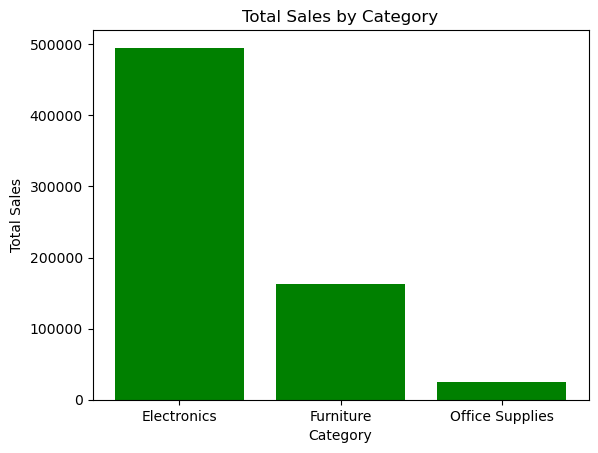

In [142]:
### Total Sales by Category

category_sales = sales_data.groupby('Category')['Sales'].sum()

plt.bar(category_sales.index, category_sales.values,color='Green')

plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.title("Total Sales by Category")

plt.show()

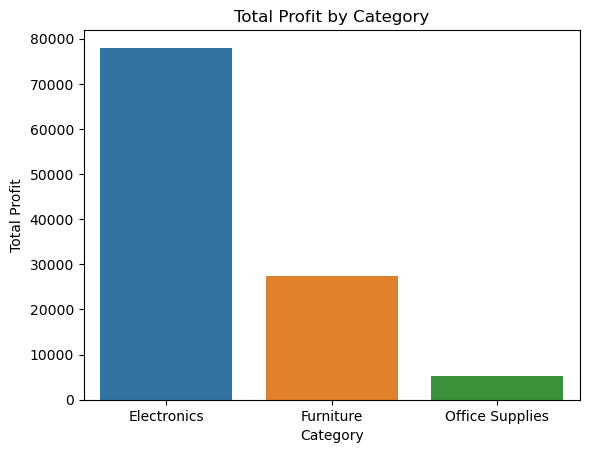

In [143]:
### Total Profit by Category

category_profit = sales_data.groupby('Category')['Profit'].sum()

sns.barplot(
        x = category_profit.index,
        y = category_profit.values
)

plt.xlabel("Category")
plt.ylabel("Total Profit")
plt.title("Total Profit by Category")

plt.show()

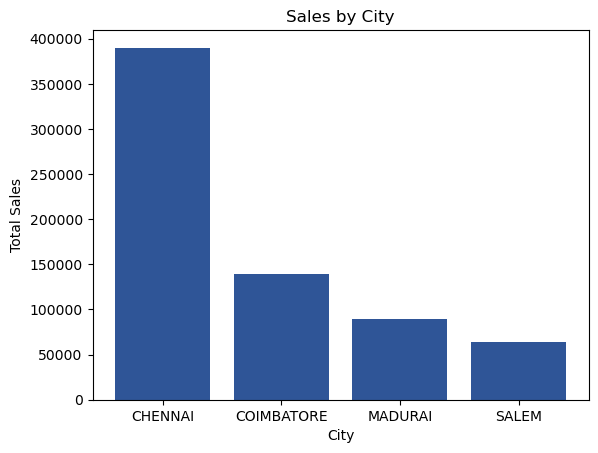

In [167]:
### Sales by City

city_sales = sales_data.groupby('City')['Sales'].sum()

plt.bar(city_sales.index,city_sales.values,color = '#2F5597')

plt.title("Sales by City")
plt.xlabel("City")
plt.ylabel("Total Sales")
plt.show()

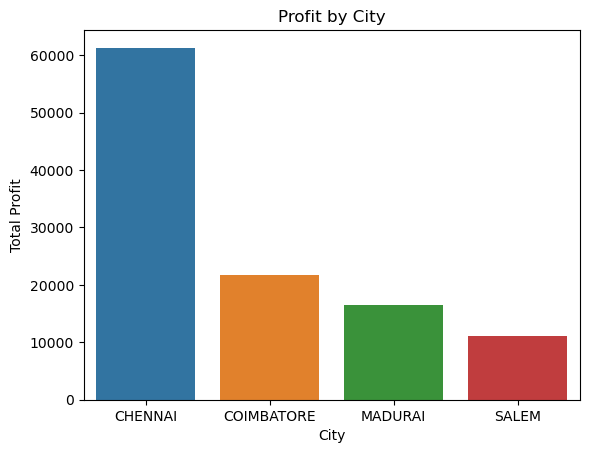

In [168]:
### Profit by City

city_profit = sales_data.groupby('City')['Profit'].sum()

sns.barplot(
    x = city_profit.index ,
    y = city_profit.values
)

plt.title("Profit by City")
plt.xlabel("City")
plt.ylabel("Total Profit")

plt.show()

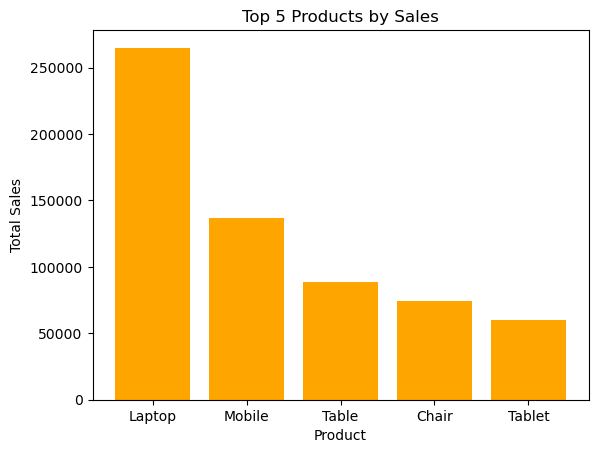

In [169]:
### Top 5 Products by Sales

top_product = sales_data.groupby('Product')['Sales'].sum().sort_values(ascending=False).head(5)

plt.bar(top_product.index, top_product.values,color="Orange")

plt.title("Top 5 Products by Sales")
plt.xlabel("Product")
plt.ylabel("Total Sales")

plt.show()

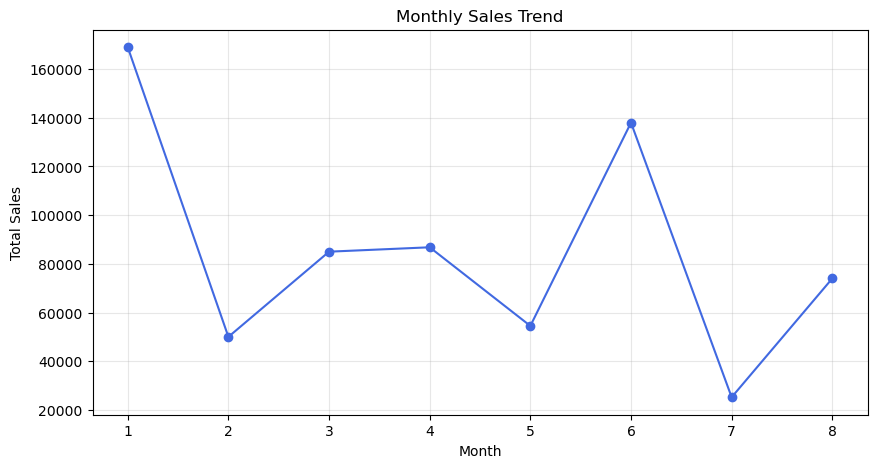

In [147]:
### Monthly Sales

monthly_sales = sales_data.groupby('Month')['Sales'].sum()

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker='o',
    color='royalblue'
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(monthly_sales.index)

plt.grid(alpha=0.3)
plt.show()

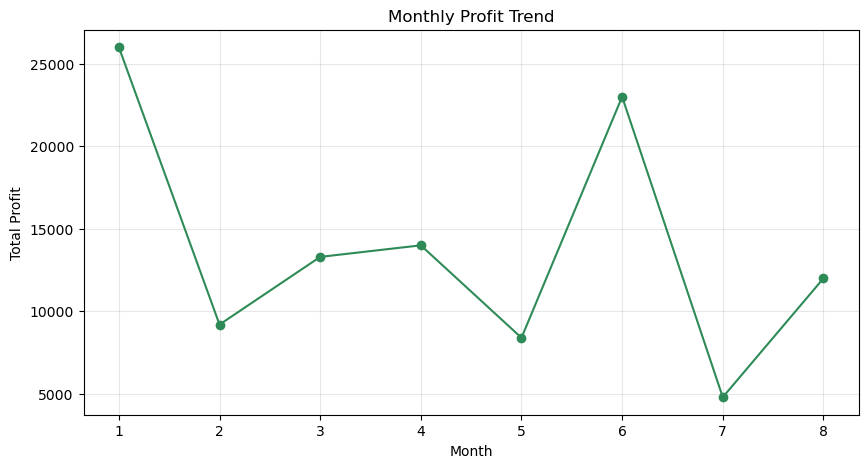

In [148]:
### Monthly Profit

monthly_profit = sales_data.groupby('Month')['Profit'].sum()

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_profit.index,
    monthly_profit.values,
    marker='o',
    color='seagreen'
)

plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Total Profit")
plt.xticks(monthly_profit.index)

plt.grid(alpha=0.3)
plt.show()

## 7.2 Customer Visualization

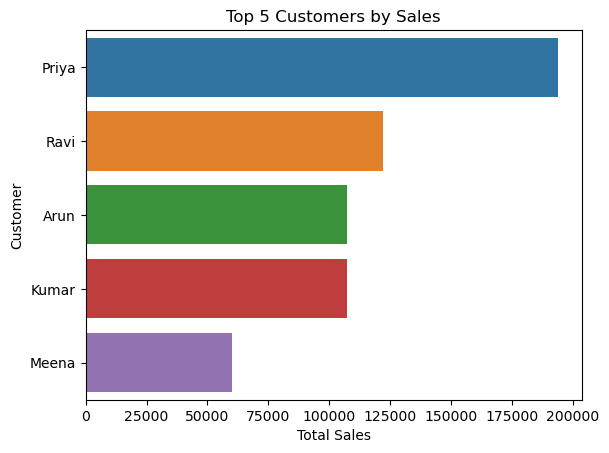

In [149]:
### Top Customers by Sales

top_customers_sales =(
     sales_data.groupby('Customer')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

sns.barplot(
    x=top_customers_sales.values,
    y=top_customers_sales.index
)

plt.title("Top 5 Customers by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Customer")

plt.show()

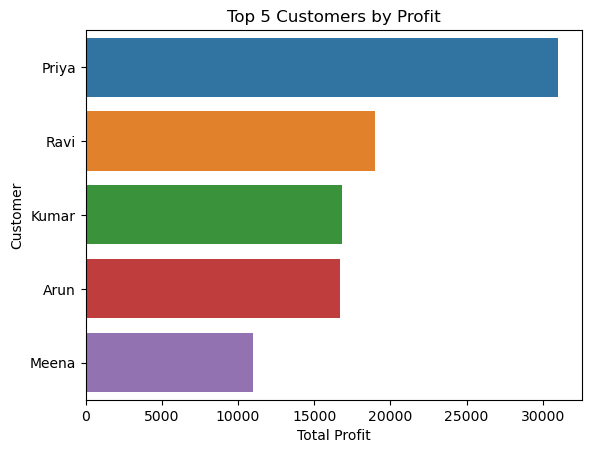

In [150]:
### Top Customers by Profit

top_customers_profit =(
         sales_data.groupby('Customer')['Profit']
        .sum()
        .sort_values(ascending=False)
        .head(5)
)
sns.barplot(
    x=top_customers_profit.values,
    y=top_customers_profit.index
)

plt.title("Top 5 Customers by Profit")
plt.xlabel("Total Profit")
plt.ylabel("Customer")

plt.show()

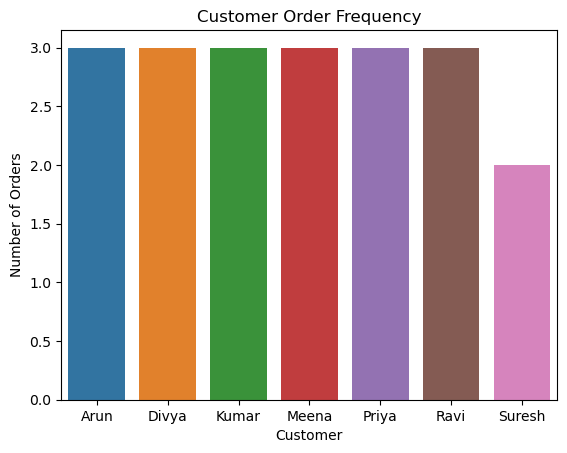

In [151]:
### Customer Order Frequency

customer_orders = (
    sales_data.groupby('Customer')['Order_ID']
    .count()
    .sort_values(ascending=False)
)

sns.barplot(
    x=customer_orders.index,
    y=customer_orders.values
)

plt.title("Customer Order Frequency")
plt.xlabel("Customer")
plt.ylabel("Number of Orders")

plt.show()

## 7.3 Distribution Analysis

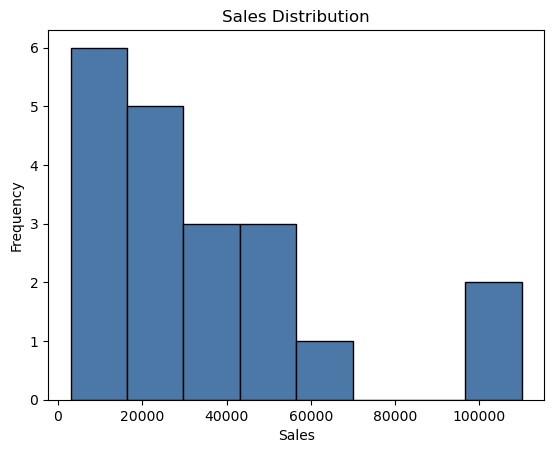

In [152]:
### Sales Distribution

plt.hist(
    sales_data['Sales'],
    bins=8,
    color='#4C78A8',
    edgecolor='black'
)

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

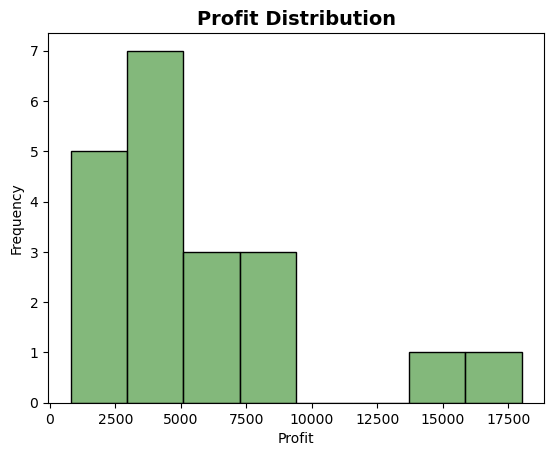

In [153]:
### Profit Distribution

sns.histplot(
    data=sales_data,
    x='Profit',
    bins=8,
    color='#59A14F',
    edgecolor='black'
)

plt.title("Profit Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Profit")
plt.ylabel("Frequency")

plt.show()

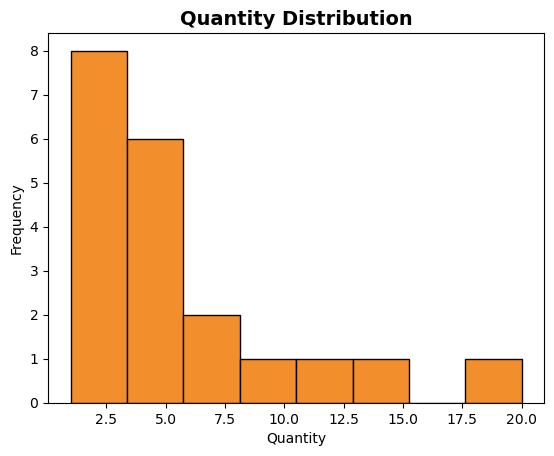

In [154]:
### Quantity Distribution

plt.hist(
    sales_data['Quantity'],
    bins=8,
    color='#F28E2B',
    edgecolor='black'
)

plt.title("Quantity Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Quantity")
plt.ylabel("Frequency")

plt.show()

## 7.4 Relationship Analysis

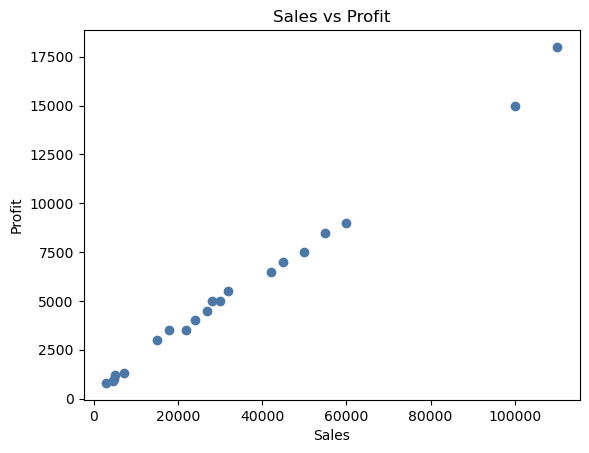

In [155]:
### Sales vs Profit

plt.scatter(
    sales_data['Sales'],
    sales_data['Profit'],
    color='#4C78A8'
)

plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.show()

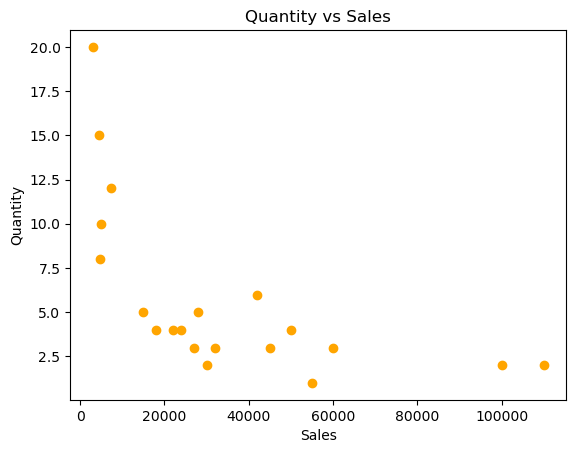

In [156]:
### Quantity vs Sales

plt.scatter(
    sales_data['Sales'],
    sales_data['Quantity'],
    color='Orange'
)

plt.title("Quantity vs Sales")
plt.xlabel("Sales")
plt.ylabel("Quantity")

plt.show()

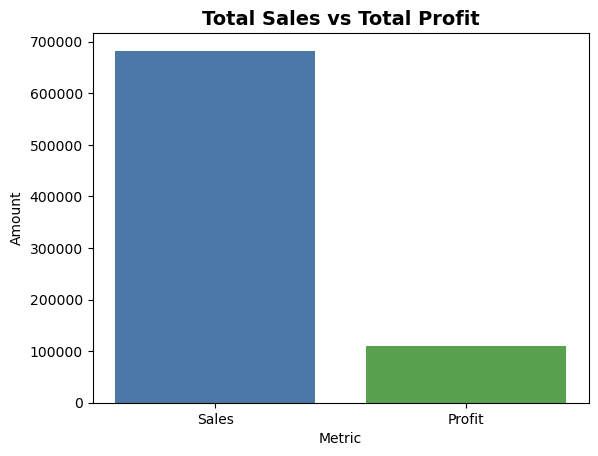

In [157]:
### Sales & Profit Comparison

comparison = sales_data[['Sales', 'Profit']].sum()

plt.bar(
    comparison.index,
    comparison.values,
    color=['#4C78A8', '#59A14F']
)

plt.title("Total Sales vs Total Profit", fontsize=14, fontweight='bold')
plt.xlabel("Metric")
plt.ylabel("Amount")

plt.show()

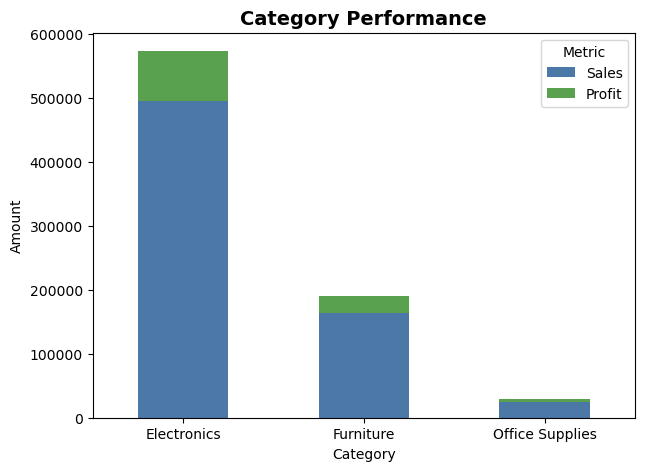

In [158]:
### Category Performance

category_summary = sales_data.groupby('Category')[['Sales', 'Profit']].sum()

category_summary.plot(
    kind='bar',
    stacked=True,
    figsize=(7, 5),
    color=['#4C78A8', '#59A14F']
)

plt.title("Category Performance", fontsize=14, fontweight='bold')
plt.xlabel("Category")
plt.ylabel("Amount")

plt.xticks(rotation=0)
plt.legend(title="Metric")

plt.show()

## 7.5 Portfolio-Level Visualization

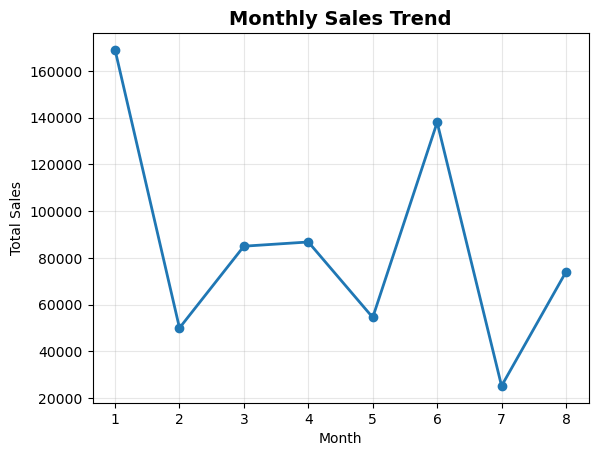

In [159]:
# ==========================================
# FINAL EDA VISUALIZATION
# ==========================================

### Monthly Sales Trend

monthly_sales =sales_data.groupby('Month')['Sales'].sum()

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker='o',
    linewidth=2
)

plt.title("Monthly Sales Trend", fontsize=14, fontweight='bold')
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.grid(alpha=0.3)
plt.show()

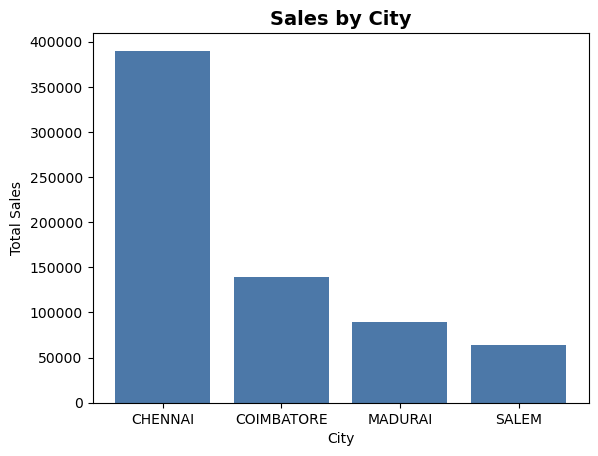

In [160]:
### Sales by City

city_sales = sales_data.groupby('City')['Sales'].sum()

plt.bar(
    city_sales.index,
    city_sales.values,
    color='#4C78A8'
)

plt.title("Sales by City", fontsize=14, fontweight='bold')
plt.xlabel("City")
plt.ylabel("Total Sales")

plt.xticks(rotation=0)
plt.show()

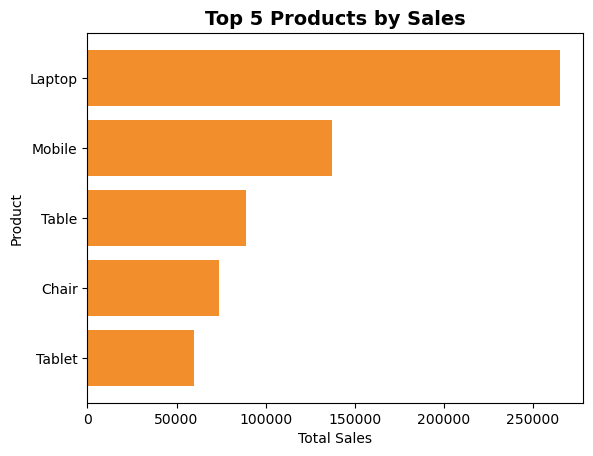

In [161]:
### Top 5 Products by Sales


top_products = (
    sales_data.groupby('Product')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

plt.barh(
    top_products.index,
    top_products.values,
    color='#F28E2B'
)

plt.title("Top 5 Products by Sales", fontsize=14, fontweight='bold')
plt.xlabel("Total Sales")
plt.ylabel("Product")

plt.gca().invert_yaxis()
plt.show()


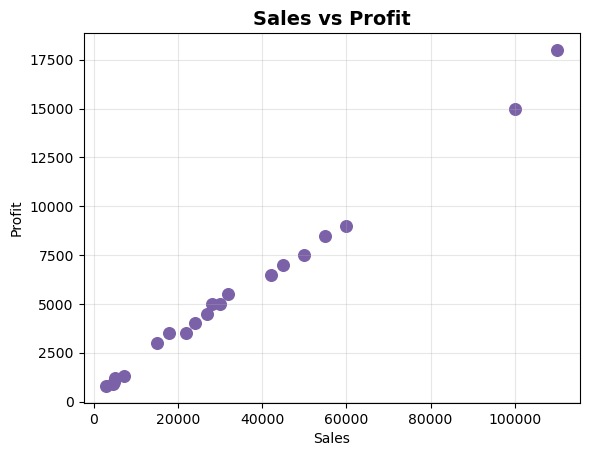

In [133]:
### Sales vs Profit

plt.scatter(
    sales_data['Sales'],
    sales_data['Profit'],
    color='#7B61A8',
    s=70
)

plt.title("Sales vs Profit", fontsize=14, fontweight='bold')
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.grid(alpha=0.3)
plt.show()

# 8. Business Insights

In [ ]:
### Overall Sales Performance

Total Sales:  682500
Average Sales per Order: 34125.0
Highest-Value Order: 110000
Lowest-Value Order:  3000
    
💡Business insight:

Total sales were 682,500, with an average of 34,125 per order.
The highest-value order was 110,000, while the lowest-value order was 3,000.

In [ ]:
### Overall Profit Performance

Total Profit: 110700
Average Profit per Order: 5535.0
Highest-Profit Order:  18000
Lowest-Profit Order:  300
    
💡Business insight:
The business generated 110,700 in total profit, with an average profit of 5,535 per order.
The most profitable order generated 18,000 profit, while the least profitable generated 300.

In [ ]:
### Best Performing Category

Highest Sales Category: Electronics
Sales: 495000

Highest Profit Category: Electronics
Profit: 78000

In [ ]:
### Category Contribution

Category
Electronics        72.53
Furniture          23.88
Office Supplies     3.59
Total             100.00

💡Business Insight:

Electronics is the dominant category, contributing 72.53% of total sales. 
Furniture contributes 23.88%, while Office Supplies contributes only 3.59%.

In [ ]:
### Best Sales City

Highest Sales City: Chennai
Total Sales: 390000
Percentage of Total Sales: 57.14%
    
💡Business Insight:

Chennai is the strongest-performing city, generating 390,000 in sales and contributing 57.14% of total sales.

In [ ]:
### Best Profit City

Highest Profit City: Chennai
Total Profit: 61300
Percentage of Total Profit: 55.38%
    
💡Business Insight

Chennai is the most profitable city, generating 61,300 in profit and contributing 55.38% of the total profit.

In [ ]:
### Best & Weakest Products

Top 3 Products by Sales:
Laptop       265000
Mobile       137000
Table         89000

Top 3 Products by Profit:
Laptop        41500
Mobile        21000
Table         15000

Lowest-Sales Product:
Pen

Lowest-Sales Value:
7500

Lowest-Profit Product:
Pen

Lowest-Profit Value:
1700

💡Business Insight

Laptop is the strongest-performing product, generating the highest sales (265,000) and highest profit (41,500).
Pen is the weakest-performing product, with the lowest sales (7,500) and lowest profit (1,700).

In [ ]:
### Customer Performance

1. Highest-sales customer: Priya — Sales: 194000

2. Highest-profit customer: Priya — Profit: 31000

3. Highest-AOV customer: Priya — AOV: 64666.67

4. Customer(s) with the most orders:
   Arun — 3
   Divya — 3
   Kumar — 3
   Meena — 3
   Priya — 3
   Ravi — 3
    
💡Business Insight:

Priya is the strongest customer overall, having the highest sales, highest profit,
and highest AOV. However, order frequency is shared by six customers, each with 3 orders.

In [ ]:
### Monthly Performance

1. Highest-sales month  : 169000  January
    
2. Lowest-sales month  : 25200 July
    
3. Highest-profit month  : 26000 January
    
4. Lowest-profit month  :  4800 July
    
5. Best profit-margin month :  19.05 % July
    
💡Business Insight:

January was the strongest month for both sales and total profit, generating 169,000 in sales and 26,000 in profit.
July had the lowest sales and profit, but it achieved the highest profit margin at 19.05%, 
indicating relatively strong profitability despite lower sales volume.

In [ ]:
### Final Business Findings

1. Overall Business Performance

The business generated 682,500 in total sales and 110,700 in total profit, with an average sales value of 34,125 per order.

2. Category Performance

Electronics was the best-performing category, generating 495,000 in sales and contributing 72.53% of total sales.
It also generated the highest category profit of 78,000.

3. City Performance

Chennai was the strongest-performing city, generating 390,000 in sales and 61,300 in profit.
It contributed approximately 57.14% of total sales and 55.38% of total profit.

4. Product Performance

Laptop, Mobile, and Table were the top three products by sales, generating 265,000, 137,000, and 89,000, respectively.
Among them, Laptop was the strongest-selling product.

5. Customer & Time Performance

Priya was the highest-value customer, generating 194,000 in sales,
while January was the strongest sales month with 169,000 in sales.
In contrast, July recorded the lowest sales at 25,200, but achieved the highest profit margin of 19.05%.

# 9. Conclusion

This exploratory data analysis provided an overall view of the retail business performance using sales, profit, customer, product, category, city, and monthly data.

The business generated 682,500 in total sales and 110,700 in total profit. Electronics was the strongest-performing category, while Chennai generated the highest sales and profit among the cities. Laptop was the top-selling product, and Priya was the highest-sales customer.

From the time analysis, January recorded the highest sales and profit, while July recorded the lowest sales and profit. However, July achieved the highest profit margin of 19.05%, showing that lower sales volume does not necessarily mean lower profitability.

Overall, the analysis helped identify key business strengths, weaker-performing areas, and important patterns that can support data-driven business decisions